<a href="https://colab.research.google.com/github/127003278/potato-leaf-disese-classification/blob/main/Mobile_Net.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from tensorflow.keras.models import load_model
model = load_model('potato_mobilenet_model.keras')

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 40 variables whereas the saved optimizer has 78 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
test_path = "/content/drive/MyDrive/Miniproject/Testing/Testing"

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=(224,224),
    batch_size=32,
    shuffle=False
)
class_names = test_ds.class_names
print("Test classes:", test_ds.class_names)

# Normalization (same as training)

test_ds = test_ds.map(lambda x, y: (preprocess_input(x), y))



test_ds = test_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

Found 552 files belonging to 3 classes.
Test classes: ['Early_Blight', 'Healthy', 'Late_Blight']


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

NameError: name 'test_ds' is not defined

In [ ]:
dataset_path = "/content/drive/MyDrive/Miniproject/Training/Training"

In [ ]:
dataset_path = "/content/drive/MyDrive/Miniproject/Training/Training"

3


In [ ]:

healthy_path = dataset_path + "/Healthy"

In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
from tensorflow.keras.preprocessing import image
import os
import random


In [ ]:
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [ ]:
image_list = os.listdir(healthy_path)

In [ ]:
count = 0
target_augmentations = 480

while count < target_augmentations:
    img_name = random.choice(image_list)
    img_path = os.path.join(healthy_path, img_name)

    img = image.load_img(img_path, target_size=(224,224))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)

    for batch in datagen.flow(
        x,
        batch_size=1,
        save_to_dir=healthy_path,
        save_prefix='aug',
        save_format='jpg'
    ):
        count += 1
        break
print(len(os.listdir(healthy_path)))

1985


In [ ]:
count = 0
#target_augmentations = 15
target_augmentations = 15

while count < target_augmentations:
    img_name = random.choice(image_list)
    img_path = os.path.join(healthy_path, img_name)

    img = image.load_img(img_path, target_size=(224,224))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)

    for batch in datagen.flow(
        x,
        batch_size=1,
        save_to_dir=healthy_path,
        save_prefix='aug',
        save_format='jpg'
    ):
        count += 1
        break
print(len(os.listdir(healthy_path)))

2000


In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split = 0.2,
    subset = "training",
    seed = 123,
    image_size = (224, 224),
    batch_size = 32,

)

Found 6000 files belonging to 3 classes.
Using 4800 files for training.


In [ ]:
print(train_ds.class_names)

['Early_Blight', 'Healthy', 'Late_Blight']


In [ ]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size = (224, 224),
    batch_size = 32,
)

Found 6000 files belonging to 3 classes.
Using 1200 files for validation.


In [ ]:
from tensorflow.keras import layers, models
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

In [ ]:
train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y))
val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y))

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

In [ ]:
from tensorflow.keras.applications import MobileNetV2
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),

    layers.Dense(512, activation='relu', kernel_regularizer=l2(0.001)),
    layers.Dropout(0.3),

    layers.Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
    layers.Dropout(0.3),

    layers.Dense(3, activation='softmax')
])

optimizer = SGD(
    learning_rate=0.0001,
    momentum=0.9
)

model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
reduce_lr = ReduceLROnPlateau(
    monitor = "val_loss",
    factor = 0.3,
    patience = 3,
    min_lr = 1e-6
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[early_stop,reduce_lr]
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 767s 5s/step - accuracy: 0.4892 - loss: 2.1097 - val_accuracy: 0.7592 - val_loss: 1.8332 - learning_rate: 1.0000e-04
Epoch 2/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 22s 150ms/step - accuracy: 0.6919 - loss: 1.8127 - val_accuracy: 0.8458 - val_loss: 1.6398 - learning_rate: 1.0000e-04
Epoch 3/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 23s 156ms/step - accuracy: 0.7773 - loss: 1.6641 - val_accuracy: 0.8750 - val_loss: 1.5289 - learning_rate: 1.0000e-04
Epoch 4/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 23s 152ms/step - accuracy: 0.8223 - loss: 1.5700 - val_accuracy: 0.8900 - val_loss: 1.4607 - learning_rate: 1.0000e-04
Epoch 5/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 23s 156ms/step - accuracy: 0.8413 - loss: 1.5189 - val_accuracy: 0.9050 - val_loss: 1.4124 - learning_rate: 1.0000e-04
Epoch 6/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 29s 191ms/step - accuracy: 0.8567 - loss: 1.4612 - val_accuracy: 0.9133 - val_loss: 1.3788 - learning_rate: 1.0000e-04

In [ ]:
# Unfreeze MobileNetV2 layers
base_model.trainable = True

# Freeze most layers and train only last 30 layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

In [ ]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
fine_tune_epochs = 20

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=fine_tune_epochs
)

Epoch 1/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 49s 205ms/step - accuracy: 0.8821 - loss: 1.3493 - val_accuracy: 0.8750 - val_loss: 1.4602
Epoch 2/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 23s 155ms/step - accuracy: 0.9396 - loss: 1.2120 - val_accuracy: 0.8808 - val_loss: 1.4390
Epoch 3/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 23s 150ms/step - accuracy: 0.9567 - loss: 1.1600 - val_accuracy: 0.8933 - val_loss: 1.3926
Epoch 4/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 23s 155ms/step - accuracy: 0.9660 - loss: 1.1320 - val_accuracy: 0.9083 - val_loss: 1.3281
Epoch 5/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 23s 152ms/step - accuracy: 0.9773 - loss: 1.0991 - val_accuracy: 0.9242 - val_loss: 1.2841
Epoch 6/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 23s 152ms/step - accuracy: 0.9756 - loss: 1.0912 - val_accuracy: 0.9417 - val_loss: 1.2240
Epoch 7/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 23s 156ms/step - accuracy: 0.9792 - loss: 1.0731 - val_accuracy: 0.9525 - val_loss: 1.1845
Epoch 8/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 23s 150ms/step - accuracy: 0.9854 - loss: 1

In [ ]:
test_path = "/content/drive/MyDrive/Mobile_net1/Testing/Testing"

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=(224,224),
    batch_size=32,
    shuffle=False
)
class_names = test_ds.class_names
print("Test classes:", test_ds.class_names)

# Normalization (same as training)

test_ds = test_ds.map(lambda x, y: (preprocess_input(x), y))



test_ds = test_ds.prefetch(buffer_size=tf.data.AUTOTUNE)


Found 552 files belonging to 3 classes.
Test classes: ['Early_Blight', 'Healthy', 'Late_Blight']


In [ ]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

18/18 ━━━━━━━━━━━━━━━━━━━━ 67s 3s/step - accuracy: 0.9764 - loss: 0.9789
Test Accuracy: 0.9764492511749268
Test Loss: 0.9788752198219299


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


In [ ]:

cm = confusion_matrix(y_true, y_pred)
print(cm)

[[196   0   4]
 [  0 147   5]
 [  1   3 196]]


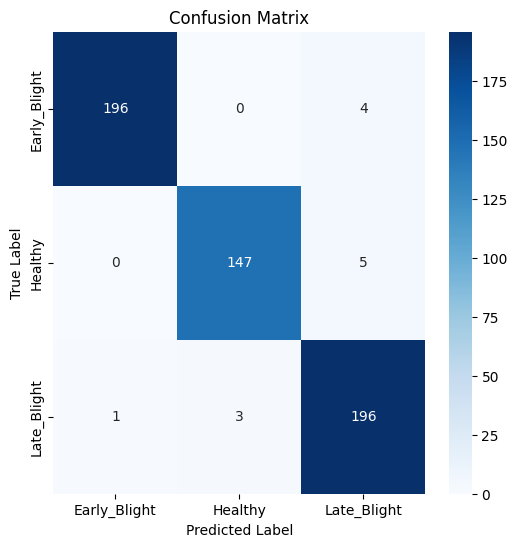

In [ ]:
plt.figure(figsize=(6,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

Early_Blight       0.99      0.98      0.99       200
     Healthy       0.98      0.97      0.97       152
 Late_Blight       0.96      0.98      0.97       200

    accuracy                           0.98       552
   macro avg       0.98      0.98      0.98       552
weighted avg       0.98      0.98      0.98       552



In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.9767468908853733
Recall: 0.9764492753623188
F1 Score: 0.9765124368835103


In [ ]:
model.save("/content/drive/MyDrive/Mobile_net1/potato_mobilenet_model.keras")

VGG-16

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

In [ ]:
IMAGE_SIZE = 224
BATCH_SIZE = 32
CHANNELS = 3

In [ ]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

Found 6000 files belonging to 3 classes.
Using 4800 files for training.
Found 6000 files belonging to 3 classes.
Using 1200 files for validation.


In [ ]:
class_names = class_names
n_classes = len(class_names)

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [ ]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3)
)

In [ ]:
for layer in base_model.layers:
    layer.trainable = False


In [ ]:
model = models.Sequential([

    layers.Rescaling(1./255, input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3)),

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(n_classes, activation='softmax')
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50
)

Epoch 1/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 625s 1s/step - accuracy: 0.6154 - loss: 0.8541 - val_accuracy: 0.8033 - val_loss: 0.6251
Epoch 2/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 33s 222ms/step - accuracy: 0.7690 - loss: 0.5820 - val_accuracy: 0.8308 - val_loss: 0.4970
Epoch 3/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 35s 237ms/step - accuracy: 0.8071 - loss: 0.4987 - val_accuracy: 0.8300 - val_loss: 0.4624
Epoch 4/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 34s 228ms/step - accuracy: 0.8238 - loss: 0.4480 - val_accuracy: 0.8575 - val_loss: 0.4018
Epoch 5/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 34s 229ms/step - accuracy: 0.8333 - loss: 0.4292 - val_accuracy: 0.8408 - val_loss: 0.4006
Epoch 6/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 35s 231ms/step - accuracy: 0.8454 - loss: 0.3911 - val_accuracy: 0.8667 - val_loss: 0.3700
Epoch 7/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 34s 229ms/step - accuracy: 0.8585 - loss: 0.3708 - val_accuracy: 0.8733 - val_loss: 0.3482
Epoch 8/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 34s 228ms/step - accuracy: 0.8612 - loss: 0.3

In [ ]:
test_path = "/content/drive/MyDrive/Miniproject/Testing/Testing"

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=(224,224),
    batch_size=32,
    shuffle=False
)
class_names = test_ds.class_names
print("Test classes:", test_ds.class_names)

# Normalization (same as training)

test_ds = test_ds.map(lambda x, y: (preprocess_input(x), y))



test_ds = test_ds.prefetch(buffer_size=tf.data.AUTOTUNE)


Found 552 files belonging to 3 classes.
Test classes: ['Early_Blight', 'Healthy', 'Late_Blight']


In [ ]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 546ms/step - accuracy: 0.9112 - loss: 0.2827
Test Accuracy: 0.9112318754196167
Test Loss: 0.2826985716819763


In [ ]:
cm = confusion_matrix(y_true, y_pred)
print(cm)

[[196   0   4]
 [  0 147   5]
 [  1   3 196]]


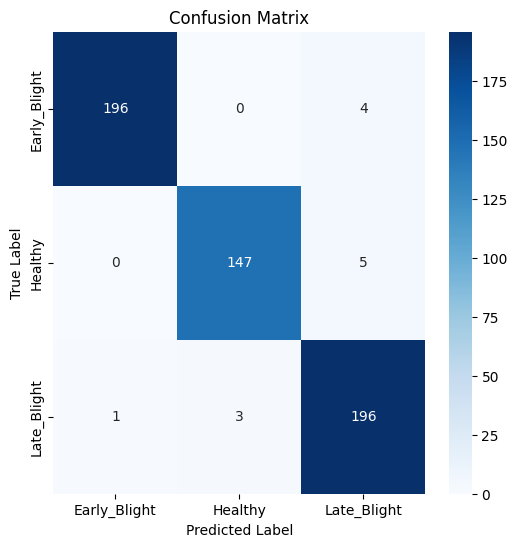

In [ ]:
plt.figure(figsize=(6,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 158ms/step - accuracy: 0.9112 - loss: 0.2827
Test Accuracy: 0.9112318754196167
Test Loss: 0.2826985716819763


In [ ]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score

In [ ]:
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 912ms/step


In [ ]:
accuracy = accuracy_score(y_true, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9112318840579711


In [ ]:
precision = precision_score(y_true, y_pred, average='weighted')
print("Precision:", precision)

Precision: 0.9134335581312133


In [ ]:
recall = recall_score(y_true, y_pred, average='weighted')
print("Recall:", recall)

Recall: 0.9112318840579711


In [ ]:
f1 = f1_score(y_true, y_pred, average='weighted')
print("F1 Score:", f1)

F1 Score: 0.9114664051028795


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.9112318840579711
Precision: 0.9134335581312133
Recall   : 0.9112318840579711
F1 Score : 0.9114664051028795


In [ ]:
model.save("/content/drive/MyDrive/Miniproject/potato_VGG_model.keras")